<a href="https://colab.research.google.com/github/sushantanand1234-sudo/ABC-XYZ-Classification/blob/main/abc_xyz_inventory_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
from google.colab import files


uploaded = files.upload()

Saving abc_xyz_dataset.csv to abc_xyz_dataset (1).csv


In [43]:
df = pd.read_csv('abc_xyz_dataset.csv')
df.head()

,Item_ID,Item_Name,Category,Jan_Demand,Feb_Demand,Mar_Demand,Apr_Demand,May_Demand,Jun_Demand,Jul_Demand,Aug_Demand,Sep_Demand,Oct_Demand,Nov_Demand,Dec_Demand,Total_Annual_Units,Price_Per_Unit,Total_Sales_Value
0,ITM_001,Surface Near,Grocery,4516,4069,4664,4653,4508,4125,4669,4210,4824,4497,4259,4782,53776,10,537760
1,ITM_002,Central Him,Grocery,4792,4964,4628,4660,4897,5015,4805,4686,4896,4536,4520,5054,57453,100,5745300
2,ITM_003,Win Everyone,Apparel,61,175,38,43,15,161,224,41,387,340,70,21,1576,2,3152
3,ITM_004,Task Save,Apparel,1145,1113,717,832,783,954,1047,894,994,978,1136,712,11305,2,22610
4,ITM_005,Hotel Teacher,Grocery,1494,2051,1400,1918,1669,1733,1695,1560,1679,1381,1591,1662,19833,10,198330


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Item_ID             1000 non-null   object
 1   Item_Name           1000 non-null   object
 2   Category            1000 non-null   object
 3   Jan_Demand          1000 non-null   int64 
 4   Feb_Demand          1000 non-null   int64 
 5   Mar_Demand          1000 non-null   int64 
 6   Apr_Demand          1000 non-null   int64 
 7   May_Demand          1000 non-null   int64 
 8   Jun_Demand          1000 non-null   int64 
 9   Jul_Demand          1000 non-null   int64 
 10  Aug_Demand          1000 non-null   int64 
 11  Sep_Demand          1000 non-null   int64 
 12  Oct_Demand          1000 non-null   int64 
 13  Nov_Demand          1000 non-null   int64 
 14  Dec_Demand          1000 non-null   int64 
 15  Total_Annual_Units  1000 non-null   int64 
 16  Price_Per_Unit      1000 

In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
# Quantity (Total_Annual_Units) by Category
category_qty = (
    df.groupby('Category')['Total_Annual_Units']
      .sum()
      .sort_values(ascending=False)
)

print(category_qty)

Category
Grocery           14328734
Apparel            1404956
Electronics         624622
Toys                306774
Home & Kitchen      296810
Name: Total_Annual_Units, dtype: int64


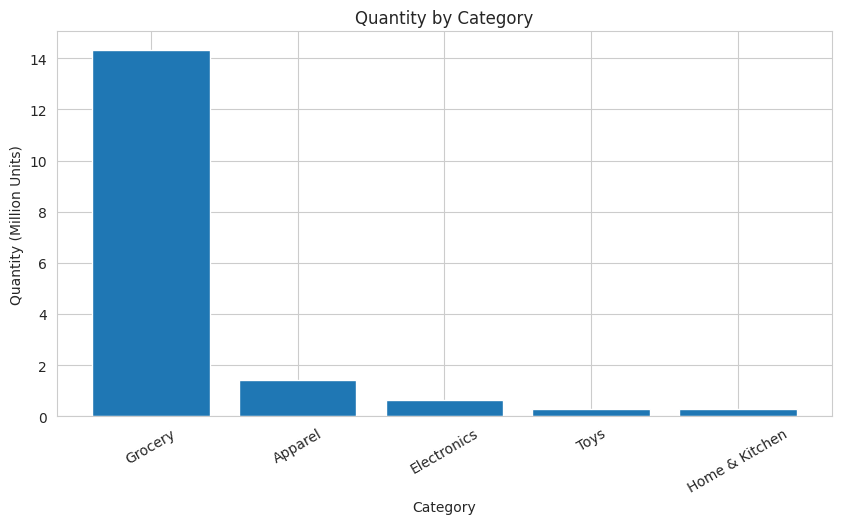

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
month_cols = ['Jan_Demand','Feb_Demand','Mar_Demand','Apr_Demand','May_Demand',
              'Jun_Demand','Jul_Demand','Aug_Demand','Sep_Demand','Oct_Demand',
              'Nov_Demand','Dec_Demand']

# ------------------------------------------------------------
#  Quantity (Total_Annual_Units) by Category
# ------------------------------------------------------------
category_qty = (
    df.groupby('Category')['Total_Annual_Units']
      .sum()
      .sort_values(ascending=False) / 1_000_000
)

plt.figure(figsize=(10,5))

plt.bar(category_qty.index, category_qty.values)

plt.ylabel("Quantity (Million Units)")
plt.xlabel("Category")
plt.title("Quantity by Category")

plt.xticks(rotation=30)

plt.show()

In [48]:
category_sales = df.groupby(['Category'])['Total_Sales_Value'].agg('sum')
category_percentage = category_sales / category_sales.sum()

result = pd.DataFrame({
    'Total_Sales_Value': category_sales,
    'Percentage_Contribution': category_percentage
})

result

,Total_Sales_Value,Percentage_Contribution
Category,,
Apparel,99381360,0.092682
Electronics,25081150,0.023390
Grocery,911737236,0.850273
Home & Kitchen,14143006,0.013190
Toys,21945148,0.020466


In [49]:
# Revenue by Category
category_rev = (
    df.groupby('Category')['Total_Sales_Value']
      .sum()
      .sort_values(ascending=False)
)

# Revenue Contribution Percentage
revenue_contribution = (
    category_rev / category_rev.sum() * 100
).round(2)

print(revenue_contribution)

Category
Grocery           85.03
Apparel            9.27
Electronics        2.34
Toys               2.05
Home & Kitchen     1.32
Name: Total_Sales_Value, dtype: float64


- **Category A (High-Value Contributors):**
  - **Grocery** contributes **~85.03%** of the total sales value, making it the most critical category to the business.
  - This category should receive the **highest priority** in terms of inventory management, promotions, and customer focus.

- **Category B (Moderate Contribution):**
  - **Apparel** contributes **~9.27%** of total sales.
  - This is a **mid-tier performer**, requiring moderate attention to maintain and possibly grow sales.

- **Category C (Low-Value Contributors):**
  - **Electronics (2.34%)**, **Toys (2.05%)**, and **Home & Kitchen (1.32%)** make up the remaining sales.
  - These categories have **low impact** on overall revenue and should be managed with **cost-efficiency in mind**, possibly with limited stock or selective marketing.


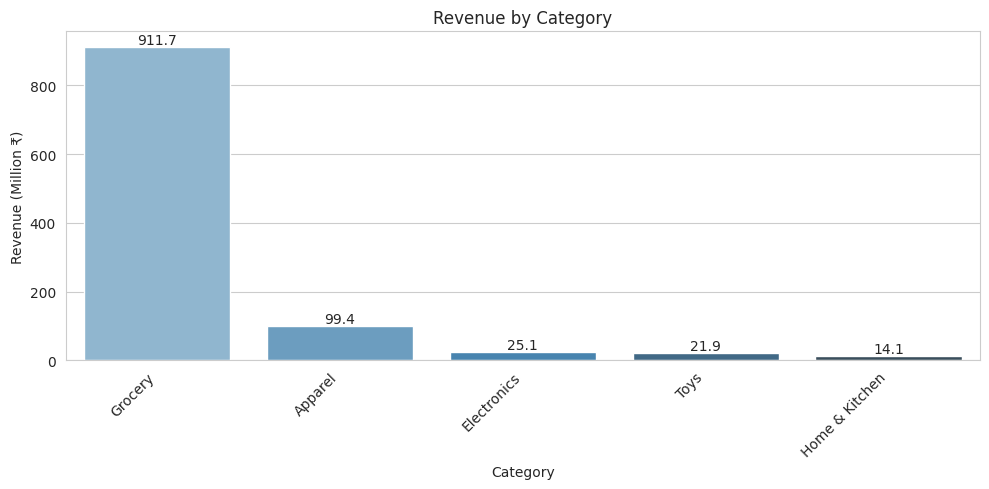

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Revenue in Millions
category_rev = (
    df.groupby('Category')['Total_Sales_Value']
      .sum()
      .sort_values(ascending=False) / 1_000_000
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=category_rev.index,
    y=category_rev.values,
    hue=category_rev.index,
    palette="Blues_d",
    legend=False
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (Million ₹)")
plt.xticks(rotation=45, ha='right')

# Add labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=10)

plt.tight_layout()
plt.show()

In [51]:
df1 = df.copy()

# ABC Classification
def abc_classification(df):
    # Sort by descending sales value
    df_abc = df.sort_values('Total_Sales_Value', ascending=False)

    # Calculate cumulative percentage
    total_sales = df_abc['Total_Sales_Value'].sum()
    df_abc['Cumulative_Pct'] = (df_abc['Total_Sales_Value'].cumsum() / total_sales) * 100

    # Assign ABC classes
    df_abc['ABC_Class'] = np.where(df_abc['Cumulative_Pct'] <= 80, 'A',
                          np.where(df_abc['Cumulative_Pct'] <= 95, 'B', 'C'))
    return df_abc



In [52]:
# XYZ Classification
def xyz_classification(df):
    # Get monthly demand columns
    months = [col for col in df.columns if '_Demand' in col]

    # Calculate coefficient of variation (CV)
    df['Avg_Demand'] = df[months].mean(axis=1)
    df['Std_Demand'] = df[months].std(axis=1)
    df['CV'] = (df['Std_Demand'] / df['Avg_Demand']) * 100

    # Assign XYZ classes
    df['XYZ_Class'] = np.where(df['CV'] < 10, 'X',
                          np.where(df['CV'] <= 25, 'Y', 'Z'))
    return df

In [53]:
# Perform classifications
df_abc = abc_classification(df1)
df_final = xyz_classification(df_abc)

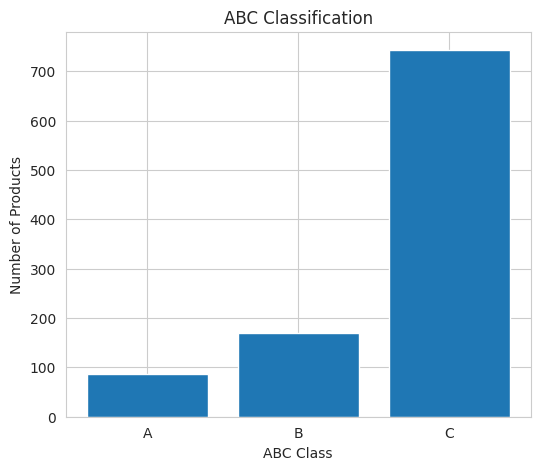

In [54]:
# ABC Class Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

abc_counts = df_final['ABC_Class'].value_counts().sort_index()

plt.bar(abc_counts.index,
        abc_counts.values)

plt.title("ABC Classification")
plt.xlabel("ABC Class")
plt.ylabel("Number of Products")

plt.show()

In [55]:
df_final['ABC_Class'].value_counts()

,count
ABC_Class,
C,743
B,170
A,87


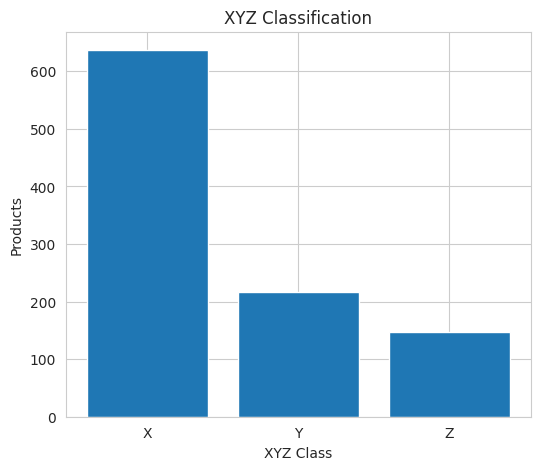

In [56]:
# XYZ Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

xyz_counts = df_final['XYZ_Class'].value_counts().sort_index()

plt.bar(xyz_counts.index,
        xyz_counts.values)

plt.title("XYZ Classification")
plt.xlabel("XYZ Class")
plt.ylabel("Products")

plt.show()

In [57]:
df_final['XYZ_Class'].value_counts()

,count
XYZ_Class,
X,637
Y,216
Z,147


In [58]:
# Combine ABC-XYZ
df_final['Combined_Class'] = df_final['ABC_Class'] + df_final['XYZ_Class']


In [59]:
# Display relevant columns
result = df_final[['Item_ID', 'Item_Name', 'Total_Sales_Value', 'ABC_Class',
                   'Avg_Demand', 'Std_Demand', 'CV', 'XYZ_Class', 'Combined_Class']]

print("ABC-XYZ Classification Results:")
result

ABC-XYZ Classification Results:


,Item_ID,Item_Name,Total_Sales_Value,ABC_Class,Avg_Demand,Std_Demand,CV,XYZ_Class,Combined_Class
924,ITM_925,Ten And,59462000,A,4955.166667,175.138300,3.534458,X,AX
511,ITM_512,Radio Race,47606000,A,3967.166667,242.380930,6.109673,X,AX
521,ITM_522,Pattern Book,37136000,A,3094.666667,199.492234,6.446324,X,AX
394,ITM_395,Animal Key,29804500,A,4967.416667,265.766972,5.350205,X,AX
168,ITM_169,Material Vote,28431000,A,4738.500000,203.303848,4.290468,X,AX
...,...,...,...,...,...,...,...,...,...
177,ITM_178,Investment Agreement,1512,C,63.000000,5.704862,9.055337,X,CX
482,ITM_483,Along Have,1456,C,60.666667,9.499601,15.658683,Y,CY
408,ITM_409,Indicate Organization,1396,C,58.166667,6.685579,11.493832,Y,CY
568,ITM_569,Worry Because,1290,C,53.750000,5.832900,10.851908,Y,CY


In [60]:
result['Combined_Class'].value_counts()

,count
Combined_Class,
CX,458
CY,157
CZ,128
BX,114
AX,65
BY,40
AY,19
BZ,16
AZ,3


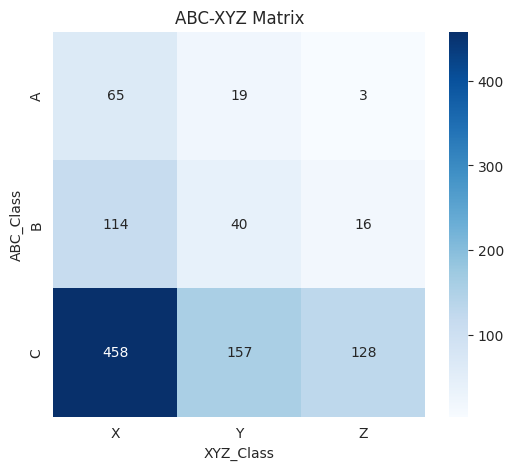

In [61]:
# ABC-XYZ Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

pivot = pd.crosstab(df_final['ABC_Class'],
                    df_final['XYZ_Class'])

plt.figure(figsize=(6,5))

sns.heatmap(pivot,
            annot=True,
            cmap='Blues',
            fmt='d')

plt.title("ABC-XYZ Matrix")
plt.show()

/tmp/ipykernel_1639/1186308366.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sku_counts.index, y=sku_counts.values, palette="Blues_d")


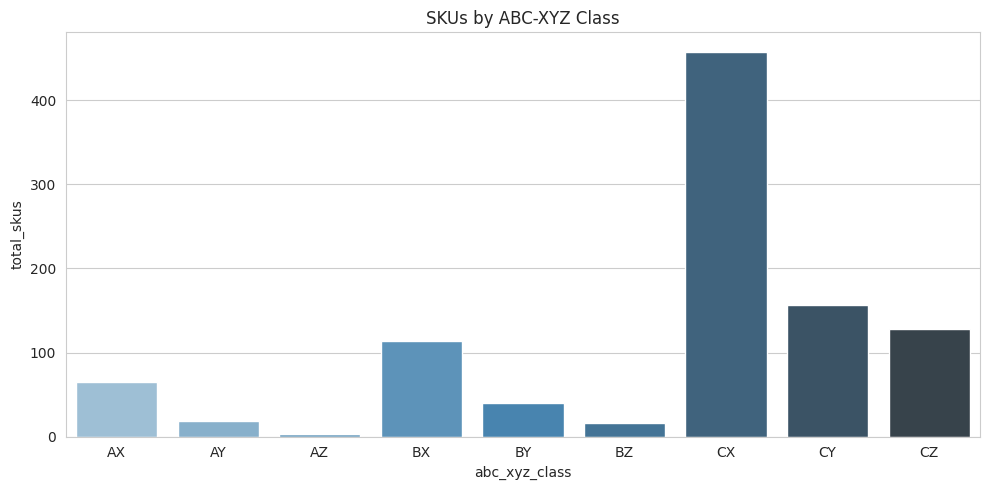

In [62]:
#Total SKUs by ABC-XYZ Class

sku_counts = df_final['Combined_Class'].value_counts().reindex(
    ['AX','AY','AZ','BX','BY','BZ','CX','CY','CZ']
)

plt.figure(figsize=(10,5))
sns.barplot(x=sku_counts.index, y=sku_counts.values, palette="Blues_d")
plt.title("SKUs by ABC-XYZ Class")
plt.xlabel("abc_xyz_class")
plt.ylabel("total_skus")
plt.tight_layout()
plt.show()

#  ABC-XYZ Analysis Conclusion

This ABC-XYZ classification evaluates inventory items based on **sales value (ABC)** and **demand variability (XYZ)**, helping identify priority items for inventory and supply chain strategies.

## Summary of Distribution:

| Combined Class | Count | Insight |
|----------------|-------|---------|
| **C-X (CX)**    | 458   | Largest group: low-value, stable-demand items. Ideal for automation and minimal intervention with basic stock control. |
| **C-Y (CY)**    | 157   | Low-value with moderate variability. Review stocking frequency and consider demand-driven replenishment. |
| **C-Z (CZ)**    | 128   | Low-value, highly unpredictable demand. Potential candidates for phase-out or make-to-order approach. |
| **B-X (BX)**    | 114   | Medium-value, stable-demand. Schedule-based stocking is effective; maintain moderate buffer. |
| **A-X (AX)**    | 65    | High-value, stable-demand. These are **strategic items** and should be prioritized for high service levels and minimal stockouts. |
| **B-Y (BY)**    | 40    | Moderate value and moderate variability. Monitor for seasonality and manage with adaptive planning. |
| **A-Y (AY)**    | 19    | High-value but somewhat variable. Require close forecasting and dynamic replenishment. |
| **B-Z (BZ)**    | 16    | Moderate value and high variability. Higher risk—review often and stock conservatively. |
| **A-Z (AZ)**    | 3     | High-value, highly unpredictable items. Critical-risk items: require custom strategies like safety stocks, vendor flexibility, or tighter forecasting. |

##  Key Takeaways

- **CX** items dominate the inventory, suggesting many low-impact but predictable items that could be managed with minimal oversight.
- **AX** items, while fewer, are **top-priority** for business continuity—ensure optimal stock levels.
- **AZ** items are **rare but high-risk**—they combine value and volatility, demanding specialized attention.
- Managing **CY** and **CZ** classes can reduce inefficiencies and free up resources from low-contributing, erratic items.



A Class ends at SKU : 87
B Class ends at SKU : 257
C Class starts from : 258


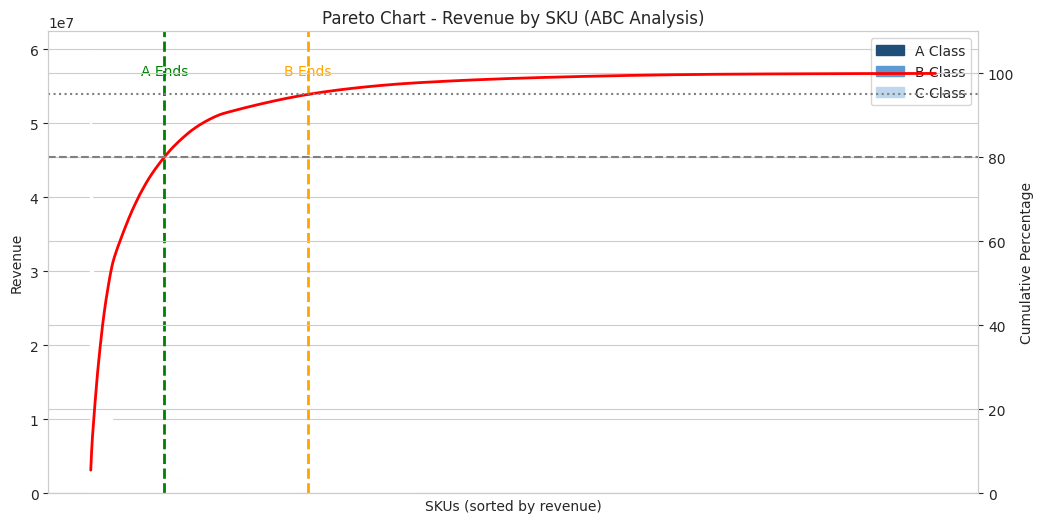

In [63]:
#Pareto Analysis
import matplotlib.pyplot as plt

# Sort SKUs by revenue
df_pareto = df_final.sort_values('Total_Sales_Value', ascending=False).reset_index(drop=True)

# Calculate cumulative revenue %
df_pareto['Cumulative_Pct'] = (
    df_pareto['Total_Sales_Value'].cumsum()
    / df_pareto['Total_Sales_Value'].sum()
) * 100

# Find ABC boundaries
A_end = (df_pareto['Cumulative_Pct'] <= 80).sum()
B_end = (df_pareto['Cumulative_Pct'] <= 95).sum()

print(f"A Class ends at SKU : {A_end}")
print(f"B Class ends at SKU : {B_end}")
print(f"C Class starts from : {B_end + 1}")

# Colors for bars
color_map = {
    'A': '#1f4e79',
    'B': '#5b9bd5',
    'C': '#bdd7ee'
}

bar_colors = df_pareto['ABC_Class'].map(color_map)

# Plot
fig, ax1 = plt.subplots(figsize=(12,6))

# Revenue bars
ax1.bar(df_pareto.index,
        df_pareto['Total_Sales_Value'],
        color=bar_colors)

ax1.set_title("Pareto Chart - Revenue by SKU (ABC Analysis)")
ax1.set_xlabel("SKUs (sorted by revenue)")
ax1.set_ylabel("Revenue")
ax1.set_xticks([])

# Cumulative percentage
ax2 = ax1.twinx()

ax2.plot(df_pareto.index,
         df_pareto['Cumulative_Pct'],
         color='red',
         linewidth=2)

ax2.set_ylabel("Cumulative Percentage")
ax2.set_ylim(0,110)

# 80% and 95% lines
ax2.axhline(80, color='gray', linestyle='--')
ax2.axhline(95, color='gray', linestyle=':')

# ABC boundaries
ax1.axvline(A_end,
            color='green',
            linestyle='--',
            linewidth=2)

ax1.axvline(B_end,
            color='orange',
            linestyle='--',
            linewidth=2)

# Labels
ax1.text(A_end,
         df_pareto['Total_Sales_Value'].max()*0.95,
         "A Ends",
         color='green',
         ha='center')

ax1.text(B_end,
         df_pareto['Total_Sales_Value'].max()*0.95,
         "B Ends",
         color='orange',
         ha='center')

# Legend
legend_handles = [
    plt.Rectangle((0,0),1,1,color=color_map['A']),
    plt.Rectangle((0,0),1,1,color=color_map['B']),
    plt.Rectangle((0,0),1,1,color=color_map['C'])
]

ax1.legend(legend_handles,
           ['A Class','B Class','C Class'],
           loc='upper right')

plt.show()

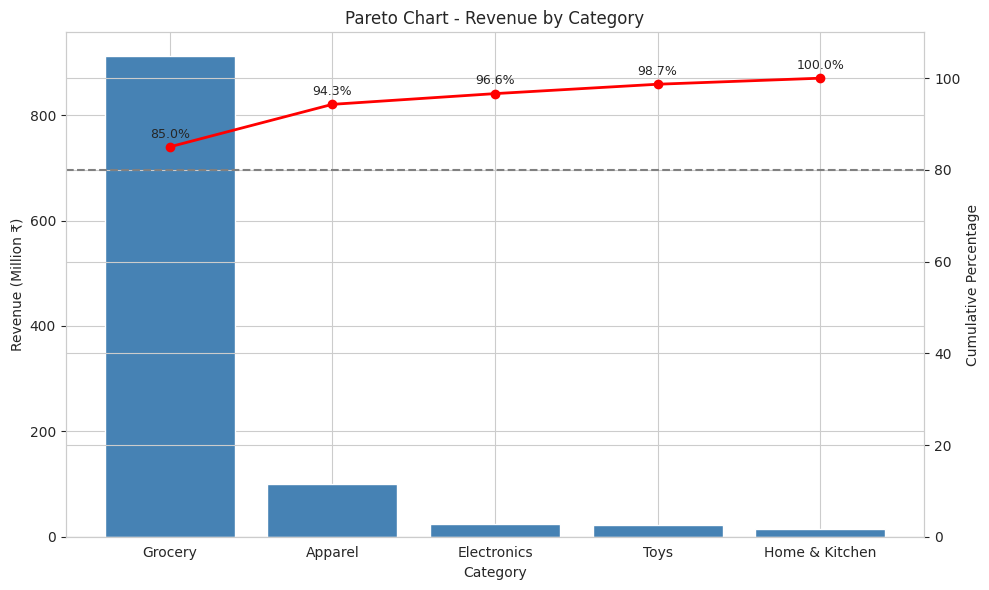

In [64]:
import matplotlib.pyplot as plt

# Revenue by category (convert to millions)
pareto = (
    df.groupby('Category')['Total_Sales_Value']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

pareto['Total_Sales_Value'] = pareto['Total_Sales_Value'] / 1_000_000

# Cumulative percentage
pareto['Cumulative_%'] = (
    pareto['Total_Sales_Value'].cumsum()
    / pareto['Total_Sales_Value'].sum()
) * 100

# Plot
fig, ax1 = plt.subplots(figsize=(10,6))

# Revenue bars
ax1.bar(
    pareto['Category'],
    pareto['Total_Sales_Value'],
    color='steelblue'
)

ax1.set_title("Pareto Chart - Revenue by Category")
ax1.set_xlabel("Category")
ax1.set_ylabel("Revenue (Million ₹)")

# Cumulative percentage
ax2 = ax1.twinx()

ax2.plot(
    pareto['Category'],
    pareto['Cumulative_%'],
    color='red',
    marker='o',
    linewidth=2
)

ax2.set_ylabel("Cumulative Percentage")
ax2.set_ylim(0,110)

# 80% reference line
ax2.axhline(80, color='gray', linestyle='--')

# Show cumulative percentage labels
for i, value in enumerate(pareto['Cumulative_%']):
    ax2.text(i, value + 2,
             f'{value:.1f}%',
             ha='center',
             fontsize=9)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

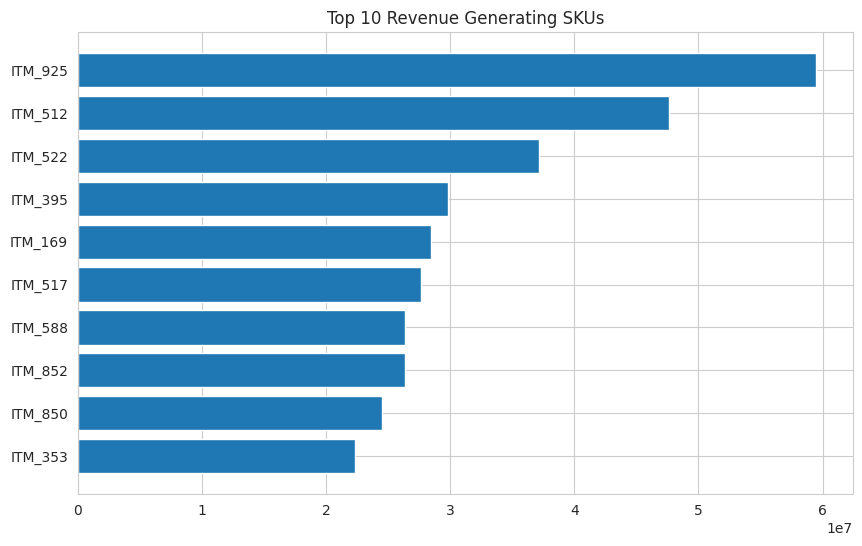

In [65]:
import matplotlib.pyplot as plt

# Create sku_summary from df
sku_summary = df.groupby('Item_ID')['Total_Sales_Value'].sum().reset_index()
sku_summary.rename(columns={'Total_Sales_Value': 'Revenue'}, inplace=True)

#Top 10 Revenue Generting SKU's
top = sku_summary.sort_values('Revenue',
                              ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.barh(top['Item_ID'],
         top['Revenue'])

plt.title("Top 10 Revenue Generating SKUs")

plt.gca().invert_yaxis()

plt.show()

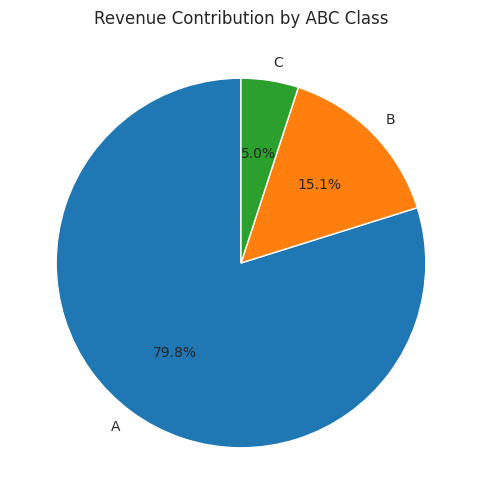

In [66]:
#Revenue Contribution By ABC Class
import matplotlib.pyplot as plt

abc_rev = df_final.groupby('ABC_Class')['Total_Sales_Value'].sum()

plt.figure(figsize=(6,6))

plt.pie(abc_rev,
        labels=abc_rev.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Revenue Contribution by ABC Class")

plt.show()

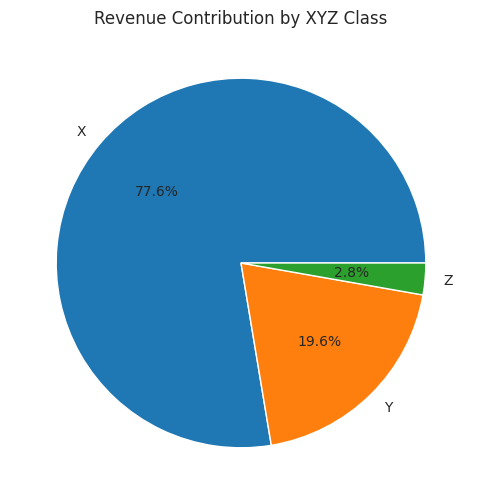

In [67]:
#Revenue Contribution By XYZ Class
xyz_rev = df_final.groupby('XYZ_Class')['Total_Sales_Value'].sum()

plt.figure(figsize=(6,6))

plt.pie(xyz_rev,
        labels=xyz_rev.index,
        autopct='%1.1f%%')

plt.title("Revenue Contribution by XYZ Class")

plt.show()

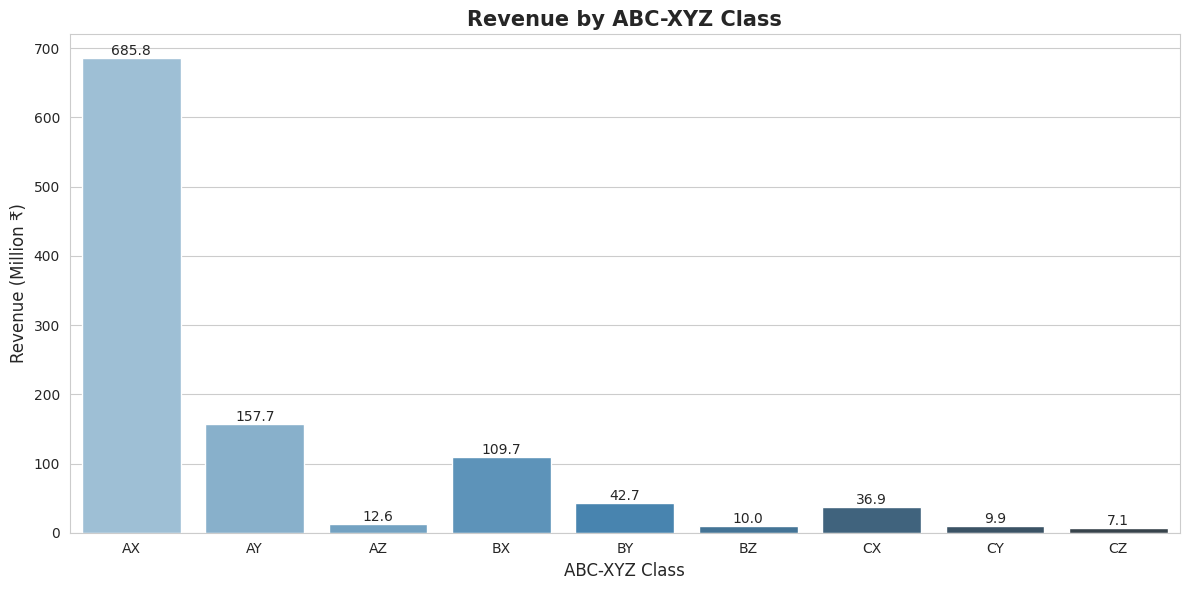

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Revenue in Millions
rev_by_class = (
    df_final.groupby('Combined_Class')['Total_Sales_Value']
    .sum()
    .reindex(['AX','AY','AZ','BX','BY','BZ','CX','CY','CZ'])
    / 1_000_000
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=rev_by_class.index,
    y=rev_by_class.values,
    hue=rev_by_class.index,
    palette="Blues_d",
    legend=False
)

plt.title("Revenue by ABC-XYZ Class", fontsize=15, fontweight='bold')
plt.xlabel("ABC-XYZ Class", fontsize=12)
plt.ylabel("Revenue (Million ₹)", fontsize=12)

# Add value labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}',
                    (p.get_x() + p.get_width()/2, height),
                    ha='center',
                    va='bottom',
                    fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1639/90494732.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=demand_by_class.index, y=demand_by_class.values, palette="Blues_d")


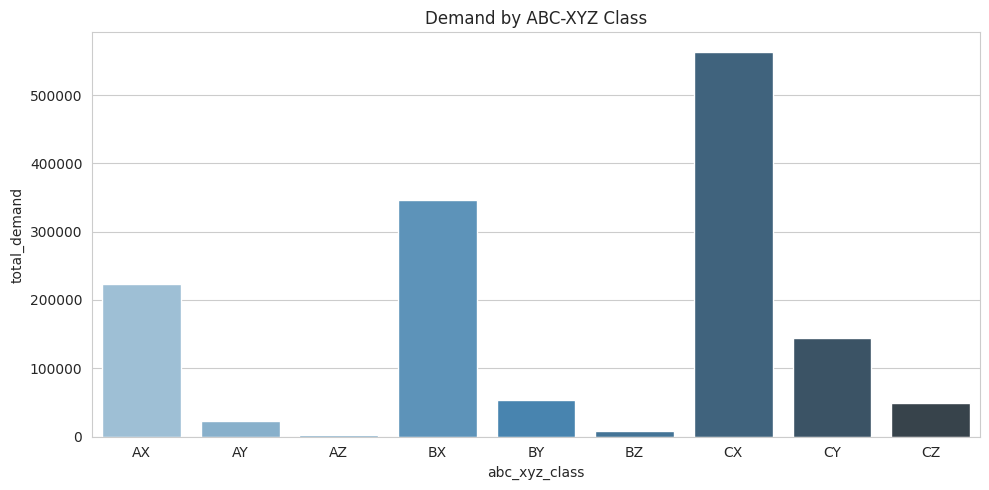

In [69]:
# ------------------------------------------------------------
#  Demand by ABC-XYZ Class
# ------------------------------------------------------------
demand_by_class = df_final.groupby('Combined_Class')['Avg_Demand'].sum().reindex(
    ['AX','AY','AZ','BX','BY','BZ','CX','CY','CZ']
)

plt.figure(figsize=(10,5))
sns.barplot(x=demand_by_class.index, y=demand_by_class.values, palette="Blues_d")
plt.title("Demand by ABC-XYZ Class")
plt.xlabel("abc_xyz_class")
plt.ylabel("total_demand")
plt.tight_layout()
plt.show()